LSTM vs GradientBoosting for PM2.5 forecasting

The key difference:
  GB model:   sees [today's features] -> predicts tomorrow
              (needs recursive hack for multi-day)
  
  LSTM model: sees [last 14 days as a SEQUENCE] -> predicts next day
              (has built-in memory, no hack needed)

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader
import pandas as pd
import numpy as np
import psycopg2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


In [2]:
conn = psycopg2.connect(
    host='localhost', dbname='indiaaq',
    user='postgres', password='8765')

df = pd.read_sql('''SELECT date, station_id, value as pm25,
           temperature, humidity, wind_speed,
           no2_value, co_value, o3_value, so2_value
    FROM daily_features
    WHERE parameter = 'pm25'
      AND value IS NOT NULL
      AND temperature IS NOT NULL
    ORDER BY station_id, date''', conn)

df = df.dropna()
df['date'] = pd.to_datetime(df['date'])
print(f"Loaded: {len(df):,} rows, {df['station_id'].nunique()} stations")

Loaded: 20,326 rows, 401 stations


/var/folders/8w/5bv12twn567_ts3f7m7q50280000gn/T/ipykernel_6653/2468259691.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('''SELECT date, station_id, value as pm25,


Notice no lag features , LSTM creates its own memory from the sequence

In [3]:
SEQUENCE_LENGTH = 14
FEATURES = ['pm25', 'temperature', 'humidity', 'wind_speed',
            'no2_value', 'co_value', 'o3_value', 'so2_value']

def create_sequences(station_df, seq_len):
    """Convert a station's time series into (input_sequence, target) pairs."""
    data = station_df[FEATURES].values.astype(np.float32)
    sequences = []
    targets = []
    
    for i in range(len(data) - seq_len):
        seq = data[i : i + seq_len]
        target = data[i + seq_len, 0]
        sequences.append(seq)
        targets.append(target)
    
    if len(sequences) == 0:
        return None, None
    return np.stack(sequences), np.array(targets, dtype=np.float32)

##### build sequences for all stations

In [5]:
scaler = StandardScaler()

all_sequences = []
all_targets = []

for sid, group in df.groupby('station_id'):
    group = group.sort_values('date').copy()
    if len(group) < SEQUENCE_LENGTH + 1:
        continue
    
    group[FEATURES] = scaler.fit_transform(group[FEATURES])
    
    seqs, tgts = create_sequences(group, SEQUENCE_LENGTH)
    if seqs is None:
        continue
    all_sequences.append(seqs)
    all_targets.append(tgts)

X = np.concatenate(all_sequences)
y = np.concatenate(all_targets)
print(f"Total sequences: {X.shape[0]}")
print(f"Each sequence: {X.shape[1]} days x {X.shape[2]} features")

Total sequences: 14968
Each sequence: 14 days x 8 features


##### Train/test split + PyTorch Dataset

In [6]:
# chronological spilit (80/20)
split = int(len(X) * 0.8)
X_train , X_test = X[:split] , X[split:]
y_train , y_test = y[:split] , y[split:]

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# PyTorch Dataset — wraps numpy arrays so DataLoader can batch them

class PM25Dataset(Dataset):
    def __init__(self, sequnces, targets):
        self.X = torch.FloatTensor(sequnces)
        self.y = torch.FloatTensor(targets)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
train_dataset = PM25Dataset(X_train , y_train)
test_dataset  = PM25Dataset(X_test, y_test)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Batches per epoch: {len(train_loader)}")

Train: 11974, Test: 2994
Batches per epoch: 188


##### The LSTM Model

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,   # 8 features per timestep
            hidden_size=hidden_size, # 64 internal memory units 
            num_layers=num_layers,   # 2 stacked LSTM  layers
            batch_first=True,        # imput shape: (batch, seq_len,features)
            
            dropout=dropout
        )   
        
        self.fc = nn.Linear(hidden_size, 1) # 64 -> (PM2.5 predections)
        
    def forward(self, x):
        out, _ = self.lstm(x)  # out shape: (batch, 14, 64)
        out  = out[:,-1,:]   # take LAST timestep only: (batch, 64)
        out  = self.fc(out)  # predict: (batch, 1)
        return out.squeeze() # flatten to (batch,)
    
model = LSTMModel(
    input_size=8,       # 8 features
    hidden_size=64,     # 64 memory cells
    num_layers=2        # 2 stacked layers
).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"Model: {total_params:,} parameters")
print(model)

Model: 52,289 parameters
LSTMModel(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


##### training loop

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

EPOCHS = 30
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        pred = model(X_batch)          # forward pass
        loss = loss_fn(pred, y_batch)  # compute error
        
        optimizer.zero_grad()          # clear old gradients
        loss.backward()                # compute new gradients
        optimizer.step()               # update weights
        
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        test_loss = 0
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(X_batch)
            test_loss += loss_fn(pred, y_batch).item()
        test_losses.append(test_loss / len(test_loader))
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  "
              f"Train Loss: {train_losses[-1]:.4f}  "
              f"Test Loss: {test_losses[-1]:.4f}")

Epoch   5/30  Train Loss: 0.5318  Test Loss: 0.6138
Epoch  10/30  Train Loss: 0.5034  Test Loss: 0.6423
Epoch  15/30  Train Loss: 0.4618  Test Loss: 0.6770
Epoch  20/30  Train Loss: 0.4119  Test Loss: 0.7277
Epoch  25/30  Train Loss: 0.3618  Test Loss: 0.7542
Epoch  30/30  Train Loss: 0.3166  Test Loss: 0.8055


In [12]:
# Get predictions
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.extend(preds)
        all_actuals.extend(y_batch.numpy())

preds = np.array(all_preds)
actuals = np.array(all_actuals)

r2 = r2_score(actuals, preds)
mae = mean_absolute_error(actuals, preds)

print(f"LSTM v1 (overfitting, no tuning):")
print(f"  R2:   {r2:.4f}")
print(f"  MAE:  {mae:.4f} (scaled units)")
print(f"\nNote: targets are scaled, so MAE is in standard deviations, not ug/m3")

LSTM v1 (overfitting, no tuning):
  R2:   0.1849
  MAE:  0.6555 (scaled units)

Note: targets are scaled, so MAE is in standard deviations, not ug/m3


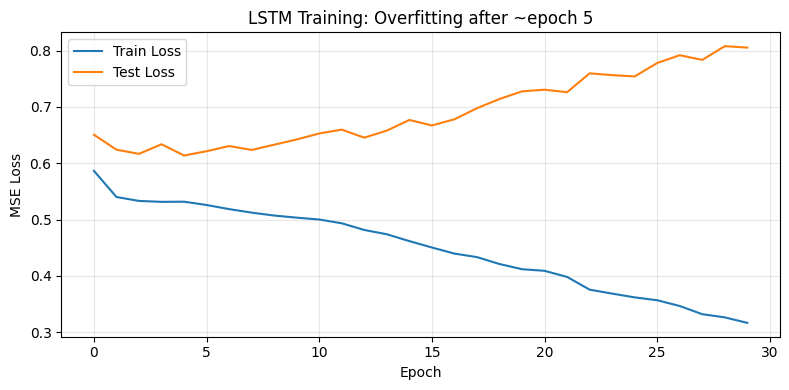

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training: Overfitting after ~epoch 5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# v2: more dropout, weight decay, early stopping
model_v2 = LSTMModel(
    input_size=8,
    hidden_size=32,      # smaller: 64 -> 32 (less capacity to memorize)
    num_layers=2,
    dropout=0.4          # higher: 0.2 -> 0.4 (randomly kills 40% of neurons)
).to(device)

optimizer = torch.optim.Adam(model_v2.parameters(), lr=0.001, weight_decay=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 50
best_test_loss = float('inf')
best_epoch = 0
patience = 10            # stop if no improvement for 10 epochs
train_losses_v2 = []
test_losses_v2 = []

for epoch in range(EPOCHS):
    # Train
    model_v2.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        pred = model_v2(X_batch)
        loss = loss_fn(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses_v2.append(epoch_loss / len(train_loader))
    
    # Evaluate
    model_v2.eval()
    with torch.no_grad():
        test_loss = 0
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model_v2(X_batch)
            test_loss += loss_fn(pred, y_batch).item()
        test_losses_v2.append(test_loss / len(test_loader))
    
    # Early stopping: save best, stop if no improvement
    if test_losses_v2[-1] < best_test_loss:
        best_test_loss = test_losses_v2[-1]
        best_epoch = epoch + 1
        torch.save(model_v2.state_dict(), '../models/lstm_pm25_v2.pt')
    
    if epoch + 1 - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1} (best was {best_epoch})")
        break
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  "
              f"Train: {train_losses_v2[-1]:.4f}  "
              f"Test: {test_losses_v2[-1]:.4f}  "
              f"Best: {best_test_loss:.4f} (ep {best_epoch})")

# Reload best weights
model_v2.load_state_dict(torch.load('../models/lstm_pm25_v2.pt', weights_only=True))
print(f"\nLoaded best model from epoch {best_epoch}")

Epoch   5/50  Train: 0.5461  Test: 0.6402  Best: 0.6378 (ep 4)
Epoch  10/50  Train: 0.5345  Test: 0.6260  Best: 0.6260 (ep 10)
Epoch  15/50  Train: 0.5250  Test: 0.6358  Best: 0.6243 (ep 12)
Epoch  20/50  Train: 0.5200  Test: 0.6269  Best: 0.6243 (ep 12)
Early stopping at epoch 22 (best was 12)

Loaded best model from epoch 12


Results (scaled units):
  LSTM v1 (overfit):  R2=0.1849  MAE=0.6555
  LSTM v2 (tuned):   R2=0.3684  MAE=0.5671

Loss curves:


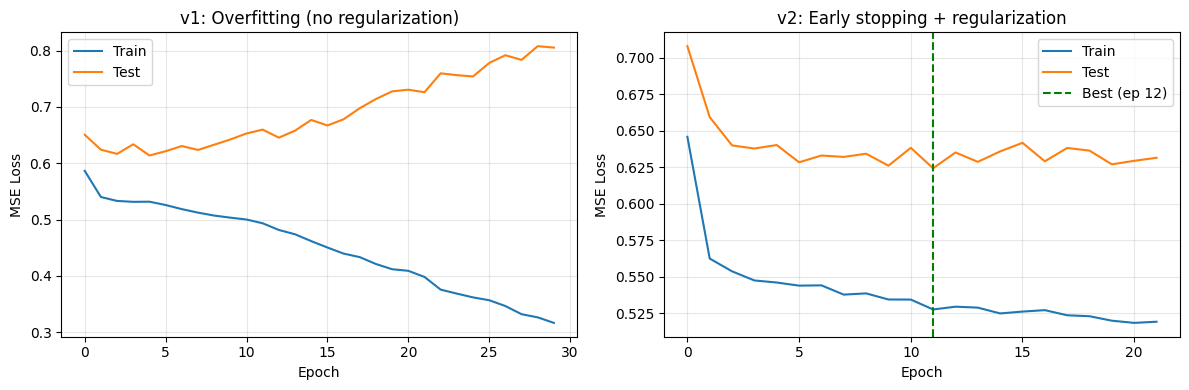

In [18]:
# Evaluate v2
model_v2.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model_v2(X_batch).cpu().numpy()
        all_preds.extend(preds)
        all_actuals.extend(y_batch.numpy())

preds_v2 = np.array(all_preds)
actuals_v2 = np.array(all_actuals)

r2_v2 = r2_score(actuals_v2, preds_v2)
mae_v2 = mean_absolute_error(actuals_v2, preds_v2)

print("Results (scaled units):")
print(f"  LSTM v1 (overfit):  R2={0.1849:.4f}  MAE={0.6555:.4f}")
print(f"  LSTM v2 (tuned):   R2={r2_v2:.4f}  MAE={mae_v2:.4f}")
print(f"\nLoss curves:")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# v1 loss curve
axes[0].plot(train_losses, label='Train')
axes[0].plot(test_losses, label='Test')
axes[0].set_title('v1: Overfitting (no regularization)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# v2 loss curve
axes[1].plot(train_losses_v2, label='Train')
axes[1].plot(test_losses_v2, label='Test')
axes[1].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best (ep {best_epoch})')
axes[1].set_title('v2: Early stopping + regularization')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/lstm_training_comparison.png', dpi=150)
plt.show()